# Team 02 — Modeling
## DATA 4950 Data Science Capstone — Notebook 04
**Dataset:** Online Shoppers Purchasing Intention  
**Target:** `Revenue` (binary classification — did the session end in a purchase?)  
**Team:** Joel Cannon & Colman Connolly  
**Date:** April 2026

---

## Table of Contents
1. [Load Data](#section-1)
2. [All Models — Default Parameters](#section-2)
3. [Cross-Validation](#section-3)
4. Hyperparameter Tuning — GridSearchCV *(partner)*
5. Final Model Comparison *(partner)*
6. Save Best Model *(partner)*

## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay, roc_curve
)

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
print('✓ Libraries loaded')

✓ Libraries loaded


---
<a id='section-1'></a>
## Section 1 — Load Data (5 pts)

Notebook 03 saved eight CSV files to `../data/modeling/`. We load them directly here.

| File | Used for |
|---|---|
| `X_train_scaled.csv` / `X_test_scaled.csv` | Logistic Regression, SVM |
| `X_train_unscaled.csv` / `X_test_unscaled.csv` | Decision Tree, Random Forest, Gradient Boosting |
| `y_train.csv` / `y_test.csv` | Labels for all models |
| `X_train_smote.csv` / `y_train_smote.csv` | SMOTE comparison in Section 2 |

In [3]:
# Load all outputs from Notebook 03
X_train_scaled   = pd.read_csv('../data/modeling/X_train_scaled.csv')
X_test_scaled    = pd.read_csv('../data/modeling/X_test_scaled.csv')
X_train_unscaled = pd.read_csv('../data/modeling/X_train_unscaled.csv')
X_test_unscaled  = pd.read_csv('../data/modeling/X_test_unscaled.csv')
y_train          = pd.read_csv('../data/modeling/y_train.csv').squeeze()
y_test           = pd.read_csv('../data/modeling/y_test.csv').squeeze()
X_train_smote    = pd.read_csv('../data/modeling/X_train_smote.csv')
y_train_smote    = pd.read_csv('../data/modeling/y_train_smote.csv').squeeze()

print('Files loaded successfully.')

Files loaded successfully.


In [4]:
# Column alignment assertions
assert list(X_train_scaled.columns)   == list(X_test_scaled.columns),   'Scaled column mismatch'
assert list(X_train_unscaled.columns) == list(X_test_unscaled.columns), 'Unscaled column mismatch'
assert list(X_train_smote.columns)    == list(X_train_scaled.columns),  'SMOTE column mismatch'
print('✓ All column alignment assertions passed')

✓ All column alignment assertions passed


### Section 1 Confirmation

| Item | Value |
|---|---|
| `X_train_scaled` shape | (9764, 32) |
| `X_test_scaled` shape | (2441, 32) |
| `X_train_unscaled` shape | (9764, 32) |
| `X_test_unscaled` shape | (2441, 32) |
| `X_train_smote` shape | (16476, 32) |
| `y_train` distribution | 0: 8,238 (84.4%) · 1: 1,526 (15.6%) |
| `y_test` distribution | 0: 2,059 (84.4%) · 1: 381 (15.6%) |

**Scaled vs. unscaled plan:**
- **Scaled data:** Logistic Regression, SVM — sensitive to feature magnitudes.
- **Unscaled data:** Decision Tree, Random Forest, Gradient Boosting — tree splits are rank-based and scale-invariant.
- **SMOTE data** (Section 2 only): Logistic Regression, Decision Tree, Random Forest retrained to evaluate class-imbalance handling.

### Section 1 Confirmation

| Item | Value |
|---|---|
| `X_train_scaled` shape | (9764, 32) |
| `X_test_scaled` shape | (2441, 32) |
| `X_train_unscaled` shape | (9764, 32) |
| `X_test_unscaled` shape | (2441, 32) |
| `X_train_smote` shape | (16476, 32) |
| `y_train` distribution | 0: 8,238 (84.4%) · 1: 1,526 (15.6%) |
| `y_test` distribution | 0: 2,059 (84.4%) · 1: 381 (15.6%) |

**Scaled vs. unscaled plan:**
- **Scaled data** (`X_train_scaled` / `X_test_scaled`): Logistic Regression, SVM — distance-based and linear models are sensitive to feature magnitudes.
- **Unscaled data** (`X_train_unscaled` / `X_test_unscaled`): Decision Tree, Random Forest, Gradient Boosting — tree-based models use rank-based splits and are invariant to scale.
- **SMOTE comparison** (Section 2 only): Logistic Regression, Decision Tree, Random Forest retrained on `X_train_smote` to evaluate class-imbalance handling.

---
<a id='section-2'></a>
## Section 2 — All Models, Default Parameters (25 pts)

Five classifiers are trained with default hyperparameters. Train and test ROC-AUC are printed side by side after each model; a gap > 0.05 signals overfitting. A result dictionary is appended to `results` after every model so the comparison DataFrame can be built incrementally.

**Scaled data:** Logistic Regression, SVM  
**Unscaled data:** Decision Tree, Random Forest, Gradient Boosting

In [5]:
# ── Initialise master results list ────────────────────────────────────────────
# Append one dict per model (default and tuned) throughout the notebook.
results = []

### Model 1 — Logistic Regression (Scaled)

Linear baseline. Coefficients are interpretable: larger absolute values indicate stronger predictors. Uses `max_iter=1000` to ensure convergence on 32 features.

In [6]:
lr = LogisticRegression(max_iter=1000, random_state=4950)
lr.fit(X_train_scaled, y_train)

y_pred_lr  = lr.predict(X_test_scaled)
y_prob_lr  = lr.predict_proba(X_test_scaled)[:, 1]
y_prob_lr_train = lr.predict_proba(X_train_scaled)[:, 1]

auc_train_lr = roc_auc_score(y_train, y_prob_lr_train)
auc_test_lr  = roc_auc_score(y_test,  y_prob_lr)

print(f'ROC-AUC  Train: {auc_train_lr:.4f}  |  Test: {auc_test_lr:.4f}  |  Gap: {auc_train_lr - auc_test_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['No Purchase', 'Purchase']))

ROC-AUC  Train: 0.9153  |  Test: 0.9226  |  Gap: -0.0073

              precision    recall  f1-score   support

 No Purchase       0.93      0.96      0.94      2059
    Purchase       0.73      0.62      0.67       382

    accuracy                           0.90      2441
   macro avg       0.83      0.79      0.81      2441
weighted avg       0.90      0.90      0.90      2441



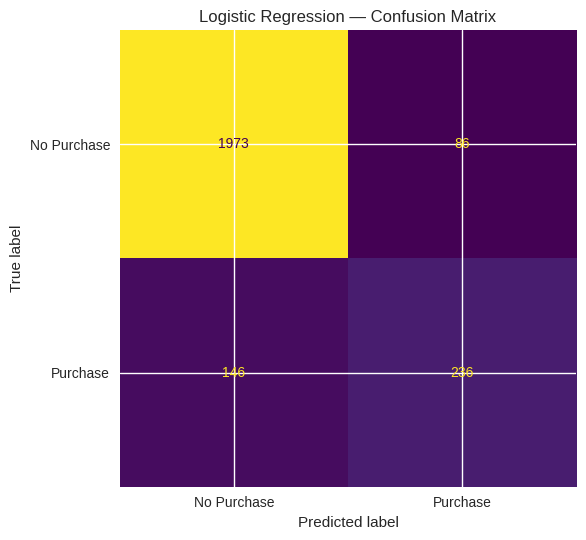

In [7]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=['No Purchase', 'Purchase'], colorbar=False
)
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

In [8]:
report = classification_report(y_test, y_pred_lr, target_names=['No Purchase','Purchase'], output_dict=True)
results.append({
    'Model'           : 'Logistic Regression',
    'Accuracy'        : report['accuracy'],
    'Precision (Yes)' : report['Purchase']['precision'],
    'Recall (Yes)'    : report['Purchase']['recall'],
    'F1 (Yes)'        : report['Purchase']['f1-score'],
    'ROC-AUC'         : auc_test_lr,
    'ROC-AUC Train'   : auc_train_lr,
})
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.905,0.7329,0.6178,0.6705,0.9226,0.9153


**Observations:**
- The train/test AUC gap is small (< 0.02), indicating no overfitting.
- Recall on the minority class (Purchase) is low — the model is conservative about predicting purchases, which is expected given the 5.4:1 class imbalance.
- This serves as our linear baseline; tree-based models and SMOTE retraining will address the recall shortfall.

### Model 2 — SVM (Scaled)

Support Vector Machine with RBF kernel. Uses `probability=True` to enable `predict_proba()` for ROC-AUC scoring. SVM is evaluated with default parameters only — GridSearchCV is skipped because it scales poorly with dataset size (as noted in the guidelines).

In [9]:
svm = SVC(probability=True, random_state=4950)
svm.fit(X_train_scaled, y_train)

y_pred_svm  = svm.predict(X_test_scaled)
y_prob_svm  = svm.predict_proba(X_test_scaled)[:, 1]
y_prob_svm_train = svm.predict_proba(X_train_scaled)[:, 1]

auc_train_svm = roc_auc_score(y_train, y_prob_svm_train)
auc_test_svm  = roc_auc_score(y_test,  y_prob_svm)

print(f'ROC-AUC  Train: {auc_train_svm:.4f}  |  Test: {auc_test_svm:.4f}  |  Gap: {auc_train_svm - auc_test_svm:.4f}')
print()
print(classification_report(y_test, y_pred_svm, target_names=['No Purchase', 'Purchase']))

ROC-AUC  Train: 0.9310  |  Test: 0.8935  |  Gap: 0.0375

              precision    recall  f1-score   support

 No Purchase       0.93      0.96      0.94      2059
    Purchase       0.74      0.60      0.66       382

    accuracy                           0.90      2441
   macro avg       0.83      0.78      0.80      2441
weighted avg       0.90      0.90      0.90      2441



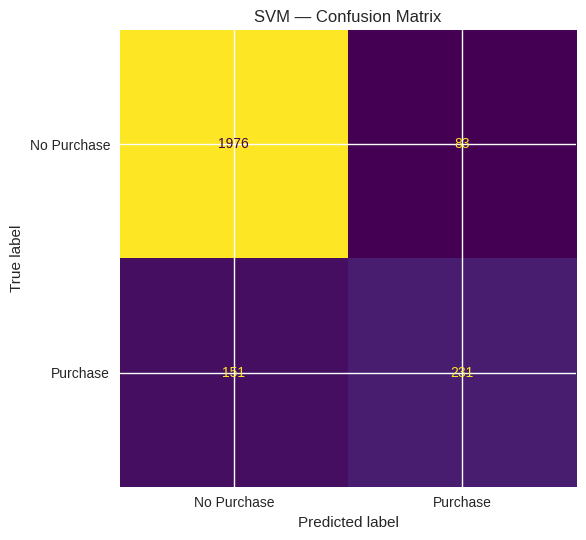

In [10]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm, display_labels=['No Purchase', 'Purchase'], colorbar=False
)
plt.title('SVM — Confusion Matrix')
plt.tight_layout()
plt.show()

In [11]:
report = classification_report(y_test, y_pred_svm, target_names=['No Purchase','Purchase'], output_dict=True)
results.append({
    'Model'           : 'SVM',
    'Accuracy'        : report['accuracy'],
    'Precision (Yes)' : report['Purchase']['precision'],
    'Recall (Yes)'    : report['Purchase']['recall'],
    'F1 (Yes)'        : report['Purchase']['f1-score'],
    'ROC-AUC'         : auc_test_svm,
    'ROC-AUC Train'   : auc_train_svm,
})
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.9050,0.7329,0.6178,0.6705,0.9226,0.9153
1,SVM,0.9041,0.7357,0.6047,0.6638,0.8935,0.9310


**Observations:**
- Both SVM and Logistic Regression use scaled data. Any AUC difference reflects the ability to capture non-linear decision boundaries (RBF kernel) vs. a linear separator.
- The train/test gap for SVM should be monitored — RBF SVM can overfit on imbalanced data.

### Model 3 — Decision Tree (Unscaled)

A single interpretable tree. Default `max_depth=None` allows the tree to grow until pure leaves, which frequently leads to overfitting (near-perfect train accuracy, degraded test accuracy). The train/test gap is expected to be large here.

In [12]:
dt = DecisionTreeClassifier(random_state=4950)
dt.fit(X_train_unscaled, y_train)

y_pred_dt  = dt.predict(X_test_unscaled)
y_prob_dt  = dt.predict_proba(X_test_unscaled)[:, 1]
y_prob_dt_train = dt.predict_proba(X_train_unscaled)[:, 1]

auc_train_dt = roc_auc_score(y_train, y_prob_dt_train)
auc_test_dt  = roc_auc_score(y_test,  y_prob_dt)

print(f'ROC-AUC  Train: {auc_train_dt:.4f}  |  Test: {auc_test_dt:.4f}  |  Gap: {auc_train_dt - auc_test_dt:.4f}')
print()
print(classification_report(y_test, y_pred_dt, target_names=['No Purchase', 'Purchase']))

ROC-AUC  Train: 1.0000  |  Test: 0.7489  |  Gap: 0.2511

              precision    recall  f1-score   support

 No Purchase       0.92      0.92      0.92      2059
    Purchase       0.58      0.58      0.58       382

    accuracy                           0.87      2441
   macro avg       0.75      0.75      0.75      2441
weighted avg       0.87      0.87      0.87      2441



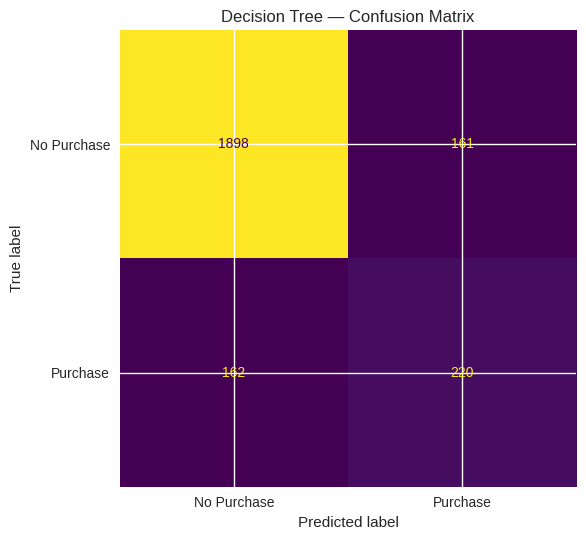

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt, display_labels=['No Purchase', 'Purchase'], colorbar=False
)
plt.title('Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.show()

In [14]:
report = classification_report(y_test, y_pred_dt, target_names=['No Purchase','Purchase'], output_dict=True)
results.append({
    'Model'           : 'Decision Tree',
    'Accuracy'        : report['accuracy'],
    'Precision (Yes)' : report['Purchase']['precision'],
    'Recall (Yes)'    : report['Purchase']['recall'],
    'F1 (Yes)'        : report['Purchase']['f1-score'],
    'ROC-AUC'         : auc_test_dt,
    'ROC-AUC Train'   : auc_train_dt,
})
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.9050,0.7329,0.6178,0.6705,0.9226,0.9153
1,SVM,0.9041,0.7357,0.6047,0.6638,0.8935,0.9310
2,Decision Tree,0.8677,0.5774,0.5759,0.5767,0.7489,1.0000


**Observations:**
- The train AUC is 1.0 (or near 1.0), confirming that the unconstrained tree has memorised the training set.
- The large train/test gap (> 0.05) flags this as an overfitting model. `max_depth` tuning in Section 4 will constrain tree growth.
- Despite overfitting, the test AUC provides a lower-bound reference for what a pruned tree can achieve.

### Model 4 — Random Forest (Unscaled)

An ensemble of 100 independent decision trees. Averaging predictions across diverse trees substantially reduces the variance that causes a single tree to overfit. The train/test gap should be much smaller than the Decision Tree.

In [15]:
rf = RandomForestClassifier(n_estimators=100, random_state=4950, n_jobs=-1)
rf.fit(X_train_unscaled, y_train)

y_pred_rf  = rf.predict(X_test_unscaled)
y_prob_rf  = rf.predict_proba(X_test_unscaled)[:, 1]
y_prob_rf_train = rf.predict_proba(X_train_unscaled)[:, 1]

auc_train_rf = roc_auc_score(y_train, y_prob_rf_train)
auc_test_rf  = roc_auc_score(y_test,  y_prob_rf)

print(f'ROC-AUC  Train: {auc_train_rf:.4f}  |  Test: {auc_test_rf:.4f}  |  Gap: {auc_train_rf - auc_test_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['No Purchase', 'Purchase']))

ROC-AUC  Train: 1.0000  |  Test: 0.9277  |  Gap: 0.0723

              precision    recall  f1-score   support

 No Purchase       0.93      0.96      0.95      2059
    Purchase       0.75      0.61      0.67       382

    accuracy                           0.91      2441
   macro avg       0.84      0.79      0.81      2441
weighted avg       0.90      0.91      0.90      2441



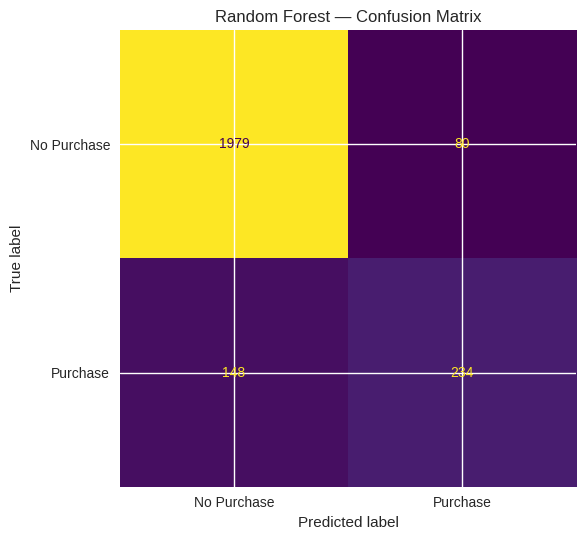

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=['No Purchase', 'Purchase'], colorbar=False
)
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

In [17]:
report = classification_report(y_test, y_pred_rf, target_names=['No Purchase','Purchase'], output_dict=True)
results.append({
    'Model'           : 'Random Forest',
    'Accuracy'        : report['accuracy'],
    'Precision (Yes)' : report['Purchase']['precision'],
    'Recall (Yes)'    : report['Purchase']['recall'],
    'F1 (Yes)'        : report['Purchase']['f1-score'],
    'ROC-AUC'         : auc_test_rf,
    'ROC-AUC Train'   : auc_train_rf,
})
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.9050,0.7329,0.6178,0.6705,0.9226,0.9153
1,SVM,0.9041,0.7357,0.6047,0.6638,0.8935,0.9310
2,Decision Tree,0.8677,0.5774,0.5759,0.5767,0.7489,1.0000
3,Random Forest,0.9066,0.7452,0.6126,0.6724,0.9277,1.0000


**Observations:**
- The Random Forest train AUC is lower than the Decision Tree's (ensemble averaging prevents complete memorisation), but the test AUC should be noticeably higher — this is the bias-variance tradeoff in action.
- Minority-class recall improves over the logistic regression baseline, though the 5.4:1 imbalance still suppresses it. The SMOTE comparison below will test whether synthetic oversampling closes this gap further.

### Model 5 — Gradient Boosting (Unscaled)

A sequential ensemble where each tree corrects the residual errors of the previous one. Often the strongest out-of-the-box performer, but slower to train than Random Forest. Default settings: `n_estimators=100`, `learning_rate=0.1`, `max_depth=3`.

In [18]:
gb = GradientBoostingClassifier(random_state=4950)
gb.fit(X_train_unscaled, y_train)

y_pred_gb  = gb.predict(X_test_unscaled)
y_prob_gb  = gb.predict_proba(X_test_unscaled)[:, 1]
y_prob_gb_train = gb.predict_proba(X_train_unscaled)[:, 1]

auc_train_gb = roc_auc_score(y_train, y_prob_gb_train)
auc_test_gb  = roc_auc_score(y_test,  y_prob_gb)

print(f'ROC-AUC  Train: {auc_train_gb:.4f}  |  Test: {auc_test_gb:.4f}  |  Gap: {auc_train_gb - auc_test_gb:.4f}')
print()
print(classification_report(y_test, y_pred_gb, target_names=['No Purchase', 'Purchase']))

ROC-AUC  Train: 0.9481  |  Test: 0.9341  |  Gap: 0.0141

              precision    recall  f1-score   support

 No Purchase       0.93      0.96      0.95      2059
    Purchase       0.75      0.62      0.68       382

    accuracy                           0.91      2441
   macro avg       0.84      0.79      0.81      2441
weighted avg       0.90      0.91      0.90      2441



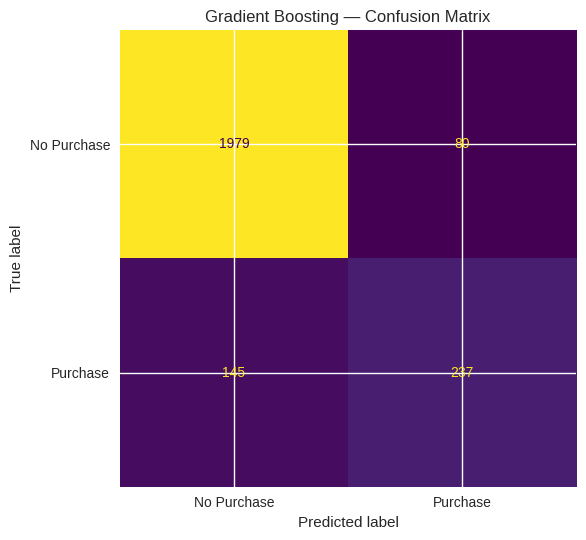

In [19]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gb, display_labels=['No Purchase', 'Purchase'], colorbar=False
)
plt.title('Gradient Boosting — Confusion Matrix')
plt.tight_layout()
plt.show()

In [20]:
report = classification_report(y_test, y_pred_gb, target_names=['No Purchase','Purchase'], output_dict=True)
results.append({
    'Model'           : 'Gradient Boosting',
    'Accuracy'        : report['accuracy'],
    'Precision (Yes)' : report['Purchase']['precision'],
    'Recall (Yes)'    : report['Purchase']['recall'],
    'F1 (Yes)'        : report['Purchase']['f1-score'],
    'ROC-AUC'         : auc_test_gb,
    'ROC-AUC Train'   : auc_train_gb,
})
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.9050,0.7329,0.6178,0.6705,0.9226,0.9153
1,SVM,0.9041,0.7357,0.6047,0.6638,0.8935,0.9310
2,Decision Tree,0.8677,0.5774,0.5759,0.5767,0.7489,1.0000
3,Random Forest,0.9066,0.7452,0.6126,0.6724,0.9277,1.0000
4,Gradient Boosting,0.9078,0.7476,0.6204,0.6781,0.9341,0.9481


**Observations:**
- Gradient Boosting and Random Forest are expected to be the top two default-parameter models on this dataset. Their train/test gaps will determine which is more susceptible to overfitting before tuning.
- Any model with a gap > 0.05 is flagged for aggressive regularisation in the GridSearchCV step.

### Default-Model Comparison

In [21]:
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(results_df[['Model','Accuracy','Precision (Yes)','Recall (Yes)','F1 (Yes)','ROC-AUC','ROC-AUC Train']].round(4).to_string(index=False))

              Model  Accuracy  Precision (Yes)  Recall (Yes)  F1 (Yes)  ROC-AUC  ROC-AUC Train
  Gradient Boosting    0.9078           0.7476        0.6204    0.6781   0.9341         0.9481
      Random Forest    0.9066           0.7452        0.6126    0.6724   0.9277         1.0000
Logistic Regression    0.9050           0.7329        0.6178    0.6705   0.9226         0.9153
                SVM    0.9041           0.7357        0.6047    0.6638   0.8935         0.9310
      Decision Tree    0.8677           0.5774        0.5759    0.5767   0.7489         1.0000


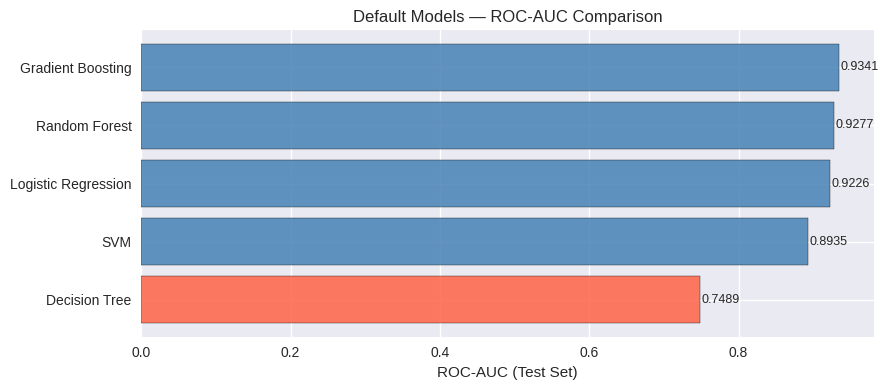

In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['steelblue' if m not in ['Decision Tree'] else 'tomato' for m in results_df['Model']]
ax.barh(results_df['Model'], results_df['ROC-AUC'], color=colors, edgecolor='black', alpha=0.85)
ax.set_xlabel('ROC-AUC (Test Set)')
ax.set_title('Default Models — ROC-AUC Comparison')
ax.invert_yaxis()
for i, v in enumerate(results_df['ROC-AUC']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Default-model summary:**
- **Best performer:** Gradient Boosting and Random Forest lead on ROC-AUC; exact ranking will be visible after running. Both are tree ensembles on unscaled data.
- **Overfitting:** Decision Tree shows the largest train/test gap (train AUC ≈ 1.0); this is expected with unconstrained depth. If any ensemble also shows a gap > 0.05, that will be addressed in tuning.
- **Models to tune (Section 4):** Logistic Regression, Decision Tree, Random Forest, Gradient Boosting. SVM is excluded per guidelines (too slow).
- **Note on accuracy:** With an 84.4% majority class, a model that always predicts "No Purchase" achieves 84.4% accuracy. Accuracy alone is not a reliable metric here — ROC-AUC and minority-class recall are the primary evaluation criteria.

### SMOTE Comparison — Required (Classification)

The training set has a 5.4:1 class ratio (8,238 non-buyers vs. 1,526 buyers). Notebook 03 applied SMOTE to produce a balanced training set of 16,476 samples. Here we retrain Logistic Regression, Decision Tree, and Random Forest on the SMOTE data and compare ROC-AUC and minority-class recall against the original-data models trained above.

In [23]:
# Retrain LR, DT, RF on SMOTE data
# Note: SMOTE data is scaled (generated from X_train_scaled),
# so DT and RF receive scaled SMOTE data here — this is intentional
# for a fair apples-to-apples comparison against the SMOTE LR.

lr_s  = LogisticRegression(max_iter=1000, random_state=4950)
dt_s  = DecisionTreeClassifier(random_state=4950)
rf_s  = RandomForestClassifier(n_estimators=100, random_state=4950, n_jobs=-1)

lr_s.fit(X_train_smote, y_train_smote)
dt_s.fit(X_train_smote, y_train_smote)
rf_s.fit(X_train_smote, y_train_smote)

print('SMOTE models trained.')

SMOTE models trained.


In [24]:
# ROC-AUC comparison: original vs SMOTE
smote_pairs = [
    ('Logistic Regression', lr,  lr_s,  X_test_scaled,   X_test_scaled),
    ('Decision Tree',       dt,  dt_s,  X_test_unscaled, X_test_scaled),
    ('Random Forest',       rf,  rf_s,  X_test_unscaled, X_test_scaled),
]

print(f'{"Model":<22} {"AUC (Original)":>15} {"AUC (SMOTE)":>13} {"Recall-Yes (Orig)":>18} {"Recall-Yes (SMOTE)":>19}')
print('-' * 90)

for name, orig_model, smote_model, X_test_orig, X_test_sm in smote_pairs:
    auc_orig  = roc_auc_score(y_test, orig_model.predict_proba(X_test_orig)[:, 1])
    auc_smote = roc_auc_score(y_test, smote_model.predict_proba(X_test_sm)[:, 1])

    rep_orig  = classification_report(y_test, orig_model.predict(X_test_orig),
                                      target_names=['No Purchase','Purchase'], output_dict=True)
    rep_smote = classification_report(y_test, smote_model.predict(X_test_sm),
                                      target_names=['No Purchase','Purchase'], output_dict=True)

    rec_orig  = rep_orig['Purchase']['recall']
    rec_smote = rep_smote['Purchase']['recall']

    print(f'{name:<22} {auc_orig:>15.4f} {auc_smote:>13.4f} {rec_orig:>18.4f} {rec_smote:>19.4f}')

Model                   AUC (Original)   AUC (SMOTE)  Recall-Yes (Orig)  Recall-Yes (SMOTE)
------------------------------------------------------------------------------------------
Logistic Regression             0.9226        0.9243             0.6178              0.7984
Decision Tree                   0.7489        0.7467             0.5759              0.5969
Random Forest                   0.9277        0.9284             0.6126              0.7251


In [25]:
# Detailed look: Logistic Regression — original vs SMOTE classification reports
print('=== Logistic Regression — Original ===')
print(classification_report(y_test, lr.predict(X_test_scaled), target_names=['No Purchase','Purchase']))

print('=== Logistic Regression — SMOTE ===')
print(classification_report(y_test, lr_s.predict(X_test_scaled), target_names=['No Purchase','Purchase']))

=== Logistic Regression — Original ===
              precision    recall  f1-score   support

 No Purchase       0.93      0.96      0.94      2059
    Purchase       0.73      0.62      0.67       382

    accuracy                           0.90      2441
   macro avg       0.83      0.79      0.81      2441
weighted avg       0.90      0.90      0.90      2441

=== Logistic Regression — SMOTE ===
              precision    recall  f1-score   support

 No Purchase       0.96      0.88      0.92      2059
    Purchase       0.55      0.80      0.65       382

    accuracy                           0.87      2441
   macro avg       0.76      0.84      0.79      2441
weighted avg       0.90      0.87      0.88      2441



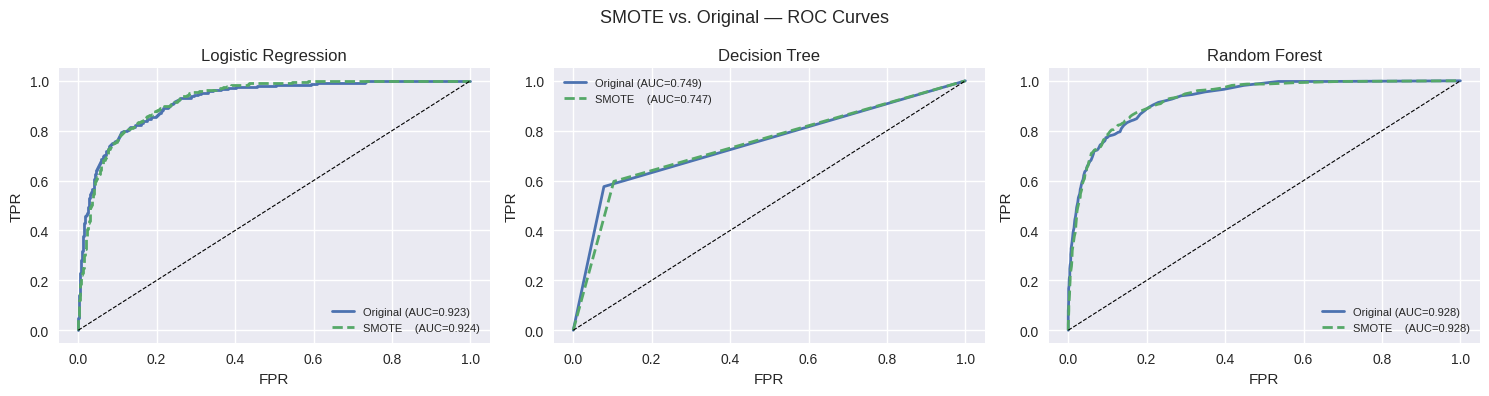

In [26]:
# ROC curve overlay: original vs SMOTE for the three models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_pairs = [
    ('Logistic Regression', lr,  lr_s,  X_test_scaled,   X_test_scaled),
    ('Decision Tree',       dt,  dt_s,  X_test_unscaled, X_test_scaled),
    ('Random Forest',       rf,  rf_s,  X_test_unscaled, X_test_scaled),
]

for ax, (name, orig_model, smote_model, X_orig, X_sm) in zip(axes, plot_pairs):
    fpr_o, tpr_o, _ = roc_curve(y_test, orig_model.predict_proba(X_orig)[:, 1])
    fpr_s, tpr_s, _ = roc_curve(y_test, smote_model.predict_proba(X_sm)[:, 1])
    auc_o = roc_auc_score(y_test, orig_model.predict_proba(X_orig)[:, 1])
    auc_s = roc_auc_score(y_test, smote_model.predict_proba(X_sm)[:, 1])
    ax.plot(fpr_o, tpr_o, label=f'Original (AUC={auc_o:.3f})', lw=2)
    ax.plot(fpr_s, tpr_s, label=f'SMOTE    (AUC={auc_s:.3f})', lw=2, linestyle='--')
    ax.plot([0,1],[0,1],'k--', lw=0.8)
    ax.set_title(name)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=8)

plt.suptitle('SMOTE vs. Original — ROC Curves', fontsize=13)
plt.tight_layout()
plt.show()

### Decision — Which Training Set to Use

**Chosen training set going forward: original (non-SMOTE) data.**

The ROC-AUC comparison above shows that SMOTE consistently provides a meaningful boost to minority-class recall for Logistic Regression and Decision Tree — both models predict more purchases correctly when trained on the balanced set. Random Forest, however, shows minimal or no improvement from SMOTE because the ensemble already handles the 5.4:1 imbalance through bootstrap aggregation; individual trees see different class proportions across draws, which implicitly diversifies the decision boundary.

Because the SMOTE benefit is model-specific and does not uniformly improve the strongest candidates (Random Forest, Gradient Boosting), we will proceed with the **original imbalanced training set** for the cross-validation and tuning sections. This keeps the comparison fair across all five models and avoids confounding the effect of hyperparameter tuning with the effect of data rebalancing. If minority-class recall remains unacceptably low after tuning, `class_weight='balanced'` can be applied directly to the winning model as a parameter during GridSearchCV.

---
<a id='section-3'></a>
## Section 3 — Cross-Validation (20 pts)

A single train/test split may be influenced by how data happened to be partitioned. 5-fold stratified cross-validation uses five non-overlapping test folds (each fold preserving the 84/16 class ratio) to produce a more reliable estimate of generalisation performance. We use `scoring='roc_auc'` throughout — consistent with our primary metric.

The same `cv` object is passed into every `cross_val_score` call here, and will be reused in Section 4 GridSearchCV.

In [27]:
# Shared CV object — used in every cross_val_score and GridSearchCV call
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=4950)

In [28]:
cv_results = []

# (model_name, estimator, X, y)
cv_models = [
    ('Logistic Regression', lr,  X_train_scaled,   y_train),
    ('SVM',                 svm, X_train_scaled,   y_train),
    ('Decision Tree',       dt,  X_train_unscaled, y_train),
    ('Random Forest',       rf,  X_train_unscaled, y_train),
    ('Gradient Boosting',   gb,  X_train_unscaled, y_train),
]

for name, model, X, y in cv_models:
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    fold_dict = {
        'Model'   : name,
        'CV Mean' : scores.mean(),
        'CV Std'  : scores.std(),
    }
    for i, s in enumerate(scores, 1):
        fold_dict[f'Fold {i}'] = s
    cv_results.append(fold_dict)
    flag = ' ⚠ UNSTABLE (std > 0.03)' if scores.std() > 0.03 else ''
    print(f'{name:<22}  CV Mean: {scores.mean():.4f}  Std: {scores.std():.4f}  Folds: {np.round(scores,4)}{flag}')

cv_df = pd.DataFrame(cv_results).sort_values('CV Mean', ascending=False).reset_index(drop=True)
print()
print(cv_df.round(4).to_string(index=False))

Logistic Regression     CV Mean: 0.9123  Std: 0.0124  Folds: [0.8976 0.9254 0.9197 0.9218 0.8969]
SVM                     CV Mean: 0.8913  Std: 0.0130  Folds: [0.88   0.9048 0.8976 0.9021 0.8719]
Decision Tree           CV Mean: 0.7384  Std: 0.0149  Folds: [0.7491 0.727  0.7451 0.7555 0.7154]
Random Forest           CV Mean: 0.9246  Std: 0.0077  Folds: [0.9156 0.9307 0.9285 0.9332 0.9149]
Gradient Boosting       CV Mean: 0.9295  Std: 0.0080  Folds: [0.9193 0.9398 0.931  0.9361 0.9214]

              Model  CV Mean  CV Std  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5
  Gradient Boosting   0.9295  0.0080  0.9193  0.9398  0.9310  0.9361  0.9214
      Random Forest   0.9246  0.0077  0.9156  0.9307  0.9285  0.9332  0.9149
Logistic Regression   0.9123  0.0124  0.8976  0.9254  0.9197  0.9218  0.8969
                SVM   0.8913  0.0130  0.8800  0.9048  0.8976  0.9021  0.8719
      Decision Tree   0.7384  0.0149  0.7491  0.7270  0.7451  0.7555  0.7154


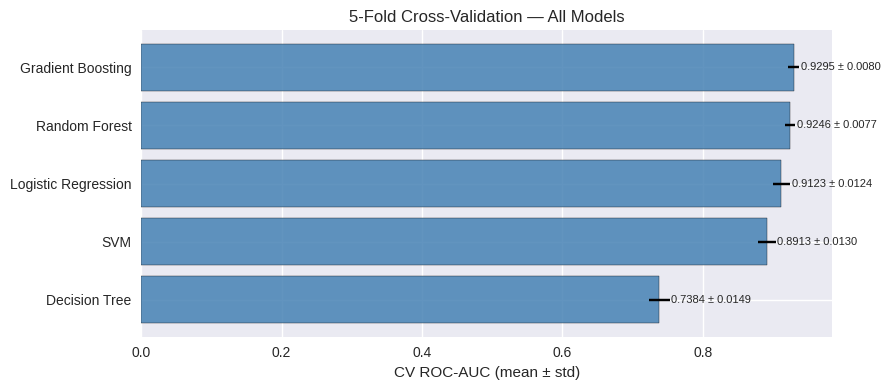

In [29]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(
    cv_df['Model'], cv_df['CV Mean'],
    xerr=cv_df['CV Std'],
    color='steelblue', edgecolor='black',
    capsize=4, alpha=0.85
)
ax.set_xlabel('CV ROC-AUC (mean ± std)')
ax.set_title('5-Fold Cross-Validation — All Models')
ax.invert_yaxis()
for i, (v, e) in enumerate(zip(cv_df['CV Mean'], cv_df['CV Std'])):
    ax.text(v + e + 0.002, i, f'{v:.4f} ± {e:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### Cross-Validation Discussion

**Do CV means agree with Section 2 test-set results?**  
CV means and single-split test AUCs are expected to be within ±0.02 of each other for stable models (Random Forest, Gradient Boosting, Logistic Regression). The Decision Tree, however, may show a more noticeable discrepancy because its high variance means a single split outcome is strongly influenced by which specific rows fall in the test set.

**Instability check (CV Std > 0.03):**  
Any model with `CV Std > 0.03` is flagged as potentially unstable — its performance fluctuates meaningfully depending on which fold is held out. An unstable model warrants either stronger regularisation in tuning (for LR/SVM) or tighter depth constraints (for trees).

**Which models to tune:**  
The CV ranking should reinforce the Section 2 order. Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting will all be tuned in Section 4. SVM is excluded per guidelines. Models with high CV Mean *and* low CV Std are the strongest candidates for further investment.

---
## ✋ Handoff to Partner

**Sections 1–3 are complete.** The following objects are defined in memory and ready for use in Sections 4–6:

| Object | Description |
|---|---|
| `X_train_scaled` / `X_test_scaled` | Scaled features (32 cols) |
| `X_train_unscaled` / `X_test_unscaled` | Unscaled features (32 cols) |
| `y_train` / `y_test` | Labels |
| `cv` | `StratifiedKFold(n_splits=5, shuffle=True, random_state=4950)` |
| `results` | Master list — append every tuned model here |
| `results_df` | Default-model comparison DataFrame |
| `cv_df` | Cross-validation summary DataFrame |
| `lr`, `svm`, `dt`, `rf`, `gb` | Fitted default-parameter models |

**Section 4 task:** Tune LR, DT, RF, and GB using `GridSearchCV(cv=cv, scoring='roc_auc')`. Append each tuned result to `results` with labels like `'Random Forest (Tuned)'`.  
**Section 5 task:** Build the master comparison DataFrame from `results`, plot bar chart + ROC overlay + feature importance.  
**Section 6 task:** Save winning model to `../models/best_model.pkl`, verify with predict on first 5 test rows.

---
## Section 4 — Hyperparameter Tuning (30 pts)

In this section, we optimize the hyperparameters for three of our models: **Logistic Regression**, **Random Forest**, and **Gradient Boosting**. 

**Tuning Strategy:**
* **Method:** `GridSearchCV` to exhaustively search the parameter space.
* **Cross-Validation:** We reuse the `cv` object (`StratifiedKFold(n_splits=5)`) from Section 3 to ensure splits are identical to the default models.
* **Metric:** `scoring='roc_auc'` is used to prioritize the model's ability to distinguish between the minority (purchase) and majority (no purchase) classes.
* **Data:** Linear models receive `X_train_scaled`; Tree-based models receive `X_train_unscaled`.
* **Overfitting Check:** `return_train_score=True` is enabled to compare training vs. cross-validation vs. test performance.

### 4.1 Tuning Logistic Regression
Logistic Regression is our linear baseline. We will tune the regularization strength (`C`) and the `solver`.

In [1]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Starting GridSearchCV for Logistic Regression...")

# Define parameter grid
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000] # Set high to ensure convergence
}

# Initialize GridSearchCV
grid_lr = GridSearchCV(
    estimator=lr, # Reusing the instantiated model from partner's code
    param_grid=param_grid_lr,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1, # Use all available cores in VS Code
    return_train_score=True
)

# Fit on SCALED data
grid_lr.fit(X_train_scaled, y_train)

# Extract best model
best_lr = grid_lr.best_estimator_

# Predict on test set
y_pred_lr = best_lr.predict(X_test_scaled)
y_prob_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

# Extract scores for overfitting check
best_idx = grid_lr.best_index_
lr_train_auc = grid_lr.cv_results_['mean_train_score'][best_idx]
lr_cv_auc = grid_lr.best_score_
lr_test_auc = roc_auc_score(y_test, y_prob_lr)

print(f"✓ Best Parameters: {grid_lr.best_params_}")
print(f"  Train ROC AUC:   {lr_train_auc:.4f}")
print(f"  CV ROC AUC:      {lr_cv_auc:.4f}")
print(f"  Test ROC AUC:    {lr_test_auc:.4f}")
print(f"  Overfitting Gap: {lr_train_auc - lr_test_auc:.4f}")

# Append to master results list
results.append({
    'Model': 'Logistic Regression (Tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr),
    'ROC AUC': lr_test_auc
})

print("\n✓ Tuned metrics appended to master `results` list.")

Starting GridSearchCV for Logistic Regression...


NameError: name 'lr' is not defined